In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
import torch
import pandas as pd
import scanpy as sc
import warnings
from sigma.toolkit import set_seed
from sigma.toolkit import clustering
from sigma.data.preparation import build_spatial_triplet_inputs, prepare_rna_protein_atac_features
import matplotlib.pyplot as plt
set_seed(2024)
warnings.filterwarnings('ignore')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


/opt/miniconda/envs/smart_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda:0


In [2]:
file_fold = '../SIGMA_data/simulated_data/'
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ADT.h5ad')
adata_omics3 = sc.read_h5ad(file_fold + 'adata_ATAC.h5ad')
adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()
adata_omics3.var_names_make_unique()
raw_count_adatas = [adata_omics1.copy(), adata_omics2.copy(), adata_omics3.copy()]
adata_omics1.obs["anno"]=pd.read_table(file_fold+"anno.txt",header=None).loc[adata_omics1.obs.index.astype("int")].values[:, 0].astype("str")
adata_omics1,adata_omics2,adata_omics3
print(adata_omics1)
print(adata_omics2)
print(adata_omics3)


AnnData object with n_obs × n_vars = 1296 × 1000
    obs: 'anno'
    uns: 'log1p'
    obsm: 'nsfac', 'spatial', 'spfac'
    varm: 'nsload', 'spload'
    layers: 'counts'
AnnData object with n_obs × n_vars = 1296 × 100
    uns: 'log1p'
    obsm: 'nsfac', 'spatial', 'spfac'
    varm: 'nsload', 'spload'
    layers: 'counts'
AnnData object with n_obs × n_vars = 1296 × 1000
    uns: 'log1p'
    obsm: 'nsfac', 'spatial', 'spfac'
    varm: 'nsload', 'spload'
    layers: 'counts'


In [3]:
adata_omics1, adata_omics2, adata_omics3, adata_list = prepare_rna_protein_atac_features(
    adata_rna=adata_omics1,
    adata_protein=adata_omics2,
    adata_atac=adata_omics3,
    min_cells=10,
    n_top_genes=3000,
    rna_n_comps=30,
    protein_n_comps=30,
    atac_n_comps=30,
    atac_scale_factor=1e4,
    atac_counts_per_cell_after=1e4,
)


In [4]:
adata_list = [adata_omics1, adata_omics2, adata_omics3]
x, edges, triplet_samples_list = build_spatial_triplet_inputs(
    adata_list=adata_list,
    rna_adata=adata_omics1,
    device=device,
    n_neighbors=4,
    edge_ratio=0.005,
    triplet_neighbors=3,
    farthest_ratio=0.6,
)


The graph contains 5184 edges, 1296 cells.
4.0000 neighbors per cell on average.
The graph contains 5184 edges, 1296 cells.
4.0000 neighbors per cell on average.
The graph contains 5184 edges, 1296 cells.
4.0000 neighbors per cell on average.
Original edges: 5184, planned new edges: 25
Actual directed new edges after deduplication: 50
  Final modality edge count: 5234
  Final modality edge count: 5234
  Final modality edge count: 5234
Distances calculation completed!
The data using feature 'feat' contains 1846 mnn_anchors
Distances calculation completed!
The data using feature 'feat' contains 1742 mnn_anchors
Distances calculation completed!
The data using feature 'feat' contains 1732 mnn_anchors


In [5]:
from sigma.training import fit_sigma_embedding
model = fit_sigma_embedding(
    adata=adata_omics1,
    features=x,
    edges=edges,
    triplet_samples_list=triplet_samples_list,
    weights=[1, 1, 1, 1, 1, 1],
    emb_dim=64,
    n_epochs=300,
    lr=1e-4,
    weight_decay=1e-6,
    device=device,
    window_size=10,
    slope=1e-4,
    seed=2024,
    move_model_to=device,
)
from sigma.reporting import cluster_and_score_ari
tool = 'mclust'  # mclust, leiden, and louvain
ari = cluster_and_score_ari(
    adata_omics1,
    label_key='anno',
    cluster_key='SIGMA',
    embedding_key='SIGMA',
    n_clusters=5,
    method=tool,
    use_pca=True,
)


100%|██████████| 300/300 [00:40<00:00,  7.41it/s]
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
0.9979194708356178


In [6]:
from sigma.reporting import report_clustering_metrics
tool = 'mclust'
scores = report_clustering_metrics(
    adata_omics1,
    label_key='anno',
    cluster_key='SIGMA',
    embedding_key='SIGMA',
    n_clusters=5,
    method=tool,
    use_pca=True,
)
ari = scores["ARI"]


fitting ...
  |======================================================================| 100%
ARI: 0.9979
NMI: 0.9967
AMI: 0.9967
Homo: 0.9969
V-measure: 0.9967
FMI: 0.9984
MI: 1.5426


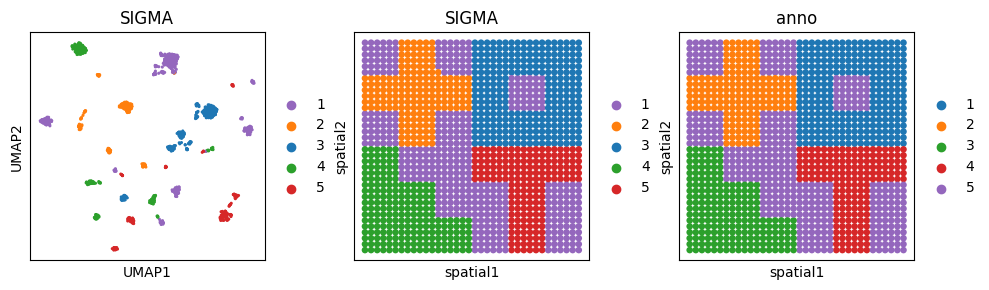

In [7]:
import matplotlib.pyplot as plt
import scanpy as sc
from sigma.reporting import default_matched_palettes
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
default_matched_palettes(
    adata_omics1,
    cluster_key="SIGMA",
    label_key="anno",
    base_colors=default_colors,
)
fig, ax_list = plt.subplots(1, 3, figsize=(10, 3))
sc.pp.neighbors(adata_omics1, use_rep='SIGMA', n_neighbors=10)
sc.tl.umap(adata_omics1)
sc.pl.umap(adata_omics1, color='SIGMA', ax=ax_list[0], title='SIGMA', s=20, show=False)
sc.pl.embedding(adata_omics1, basis='spatial', color='SIGMA', ax=ax_list[1], title='SIGMA', s=90, show=False)
sc.pl.embedding(adata_omics1, basis='spatial', color='anno', ax=ax_list[2], title='anno', s=90, show=False)
plt.tight_layout(w_pad=0.3)
plt.show()


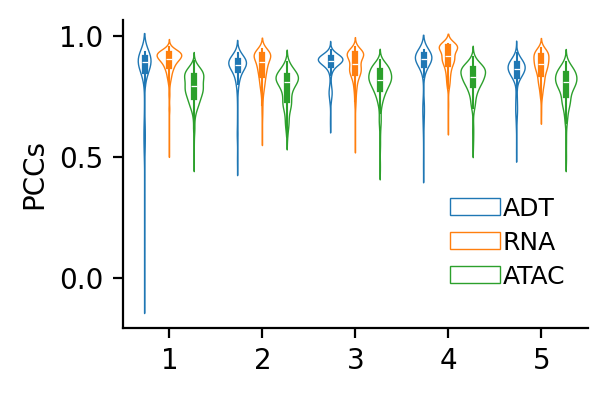

In [8]:
# =============================================
# PCC plot grouped by cluster
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import pairwise_distances
from scipy.stats import pearsonr
# Create a DataFrame grouped by cluster
df2 = pd.DataFrame(columns=["cluster", "modality", "pearsonr"])
# Use your SIGMA embedding (SIGMA key in the tutorial)
dis = pairwise_distances(adata_omics1.obsm["SIGMA"])
# dis1=ADT, dis2=RNA, dis3=ATAC (same order as in the original figure)
dis1 = pairwise_distances(adata_omics2.obsm["feat"])  # ADT
dis2 = pairwise_distances(adata_omics1.obsm["feat"])  # RNA
dis3 = pairwise_distances(adata_omics3.obsm["feat"])  # ATAC
# Compute PCC by cluster label
for i, cluster in enumerate(adata_omics1.obs['SIGMA'].values):
    corr_ADT, _ = pearsonr(dis[i], dis1[i])
    corr_RNA, _ = pearsonr(dis[i], dis2[i])
    corr_ATAC, _ = pearsonr(dis[i], dis3[i])
    df2.loc[len(df2)] = [cluster, "ADT", corr_ADT]
    df2.loc[len(df2)] = [cluster, "RNA", corr_RNA]
    df2.loc[len(df2)] = [cluster, "ATAC", corr_ATAC]
# Plot
fig, ax = plt.subplots(figsize=(3, 2), dpi=200)
sns.violinplot(
    df2,
    x="cluster",
    y="pearsonr",
    hue="modality",
    gap=0.01,
    linewidth=0.5,
    width=0.8,
    fill=False
)
ax.set_ylabel("PCCs")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1, 0.5), frameon=False, ncol=1,
          labelspacing=0.4, handletextpad=0.1, fontsize=9)
sns.despine()
plt.savefig("PCCs2_with_SIGMA.svg", format="svg", bbox_inches='tight', transparent=True)
plt.show()


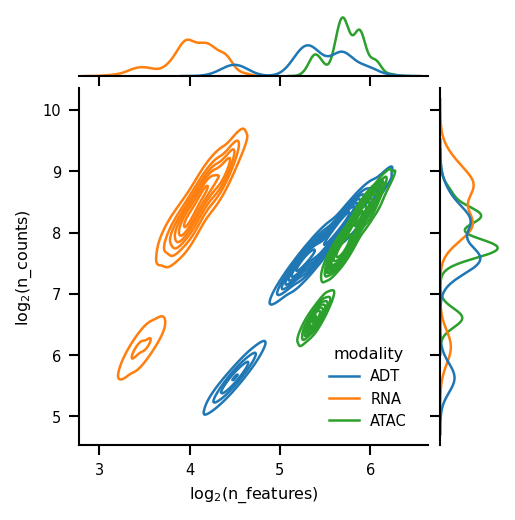

In [9]:
adata_omics11, adata_omics22, adata_omics33 = [
    adata.copy()
    for adata in raw_count_adatas
]
sc.pp.filter_cells(adata_omics11, min_genes=20)
adata_omics11.obs["n_counts"]=adata_omics11.X.sum(axis=1)
sc.pp.filter_cells(adata_omics22, min_genes=20)
adata_omics22.obs["n_counts"]=adata_omics22.X.sum(axis=1)
sc.pp.filter_cells(adata_omics33, min_genes=20)
adata_omics33.obs["n_counts"]=adata_omics33.X.sum(axis=1)
import seaborn as sns
# Switch to paper mode and scale all fonts down to 0.7x the default size
sns.set_context("paper", font_scale=0.8)
import numpy as np
df=pd.DataFrame()
for i,j in zip([adata_omics11,adata_omics22,adata_omics33],["ADT","RNA","ATAC"]):
    f=i.obs.copy()
    f=np.log(f)
    f["mod"]=j
    df=pd.concat([df,f])
df.columns=[r"log$_{2}$(n_features)",r"log$_{2}$(n_counts)","modality"]
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.loc'] = (0.7,0.03)
with plt.rc_context({'figure.dpi':150}):
    mx=sns.jointplot(data=df, x=r"log$_{2}$(n_features)", y=r"log$_{2}$(n_counts)", hue="modality", fill=False,kind="kde",height=3.5)
    plt.savefig("dis.svg",format="svg",bbox_inches='tight',transparent=True)
